# Ingeniería de Features
## Construcción y Validación de Variables para el Denoising Autoencoder

---

### Estructura del Notebook

| Sección | Contenido |
|---|---|
| §1 | Importación y auditoría de datos procesados (desde NB1) |
| §2 | Split temporal y validación de integridad |
| §3 | Normalización con StandardScaler — auditoría anti-leakage |
| §4 | Generación de tensores con ventana deslizante (T=30) |
| §5 | Análisis de separabilidad de regímenes en el espacio de features |
| §6 | Exportación de artefactos del pipeline |

---

### Principios de diseño del vector de features

Todo feature incluido en el modelo debe satisfacer simultáneamente cuatro criterios:

1. **Estacionariedad:** La serie debe tener media y varianza aproximadamente
   constantes en el tiempo para garantizar estabilidad numérica del LSTM.
   Validado mediante test ADF en NB1 — los tres features son estacionarios.
2. **Causalidad estricta:** El valor de la feature en t debe depender
   exclusivamente de información disponible en t o antes — ningún dato futuro.
   Garantizado por construcción: `vol_21d` y `vol_zscore` usan exclusivamente
   ventanas retrospectivas.
3. **Contenido informativo independiente:** Cada feature debe aportar señal
   no redundante respecto a las demás variables del vector. Validado mediante
   matriz de correlación en entrenamiento — ninguna correlación supera |0.08|.
4. **Relevancia para la detección de anomalías:** La feature debe cambiar
   de manera estadísticamente diferenciada durante los periodos de crisis
   respecto al comportamiento normal. Validado mediante tasa de detección
   heurística — COVID-19 supera el umbral p95 en el 71–77% de las sesiones
   en los cuatro activos.

---
## Importación y auditoría de datos

In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path(r"C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder/data/processed")

dfs = {}

for file in DATA_PATH.glob("*.csv"):
    ticker = file.stem
    df = pd.read_csv(file, parse_dates=True, index_col=0)
    dfs[ticker] = df

print("Activos cargados:", list(dfs.keys()))


Activos cargados: ['AVAL', 'CIB', 'EC', 'TGLS']


In [2]:
for ticker, df in dfs.items():
    print(ticker, df.shape, df.isna().sum().sum())

AVAL (2515, 8) 42
CIB (2515, 8) 42
EC (2515, 8) 42
TGLS (2515, 8) 42


In [ ]:
# ── Verificación de integridad post-carga (auditoría) ───────────────────────────────────
for ticker, df in dfs.items():
    n_nan   = df.isnull().sum().sum()
    n_dup   = df.index.duplicated().sum()
    print(f"[{ticker}]  NaN={n_nan}  |  fechas duplicadas={n_dup}  |  columnas={list(df.columns)}")

[AVAL]  NaN=42  |  fechas duplicadas=0  |  columnas=['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore']
[CIB]  NaN=42  |  fechas duplicadas=0  |  columnas=['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore']
[EC]  NaN=42  |  fechas duplicadas=0  |  columnas=['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore']
[TGLS]  NaN=42  |  fechas duplicadas=0  |  columnas=['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'vol_21d', 'vol_zscore']



Dado que los features ya vienen calculados desde el NB1, el NB2 **no recalcula**
`log_return`, `vol_21d` ni `vol_zscore`. El trabajo de esta sección se limita a:

1. Eliminar los NaN iniciales con `dropna()`
2. Aplicar el split temporal
3. Ejecutar la normalización con `StandardScaler` ajustado solo en train
4. Generar los tensores

### Impacto en el modelo

Al eliminar los 42 NaN por `dropna()`, se pierden las primeras sesiones de cada serie —
todas correspondientes a 2015, dentro del conjunto de entrenamiento. Esto no afecta la
validación ni el test, y no introduce ningún sesgo temporal.



In [ ]:
# Eliminación de NaN y split temporal ─────────────────────────────────
# Se eliminan las primeras observaciones con NaN (warm-up de vol_21d).
# Split cronológico estricto — sin shuffle, sin solapamiento.
#
# Train : 2015-01-01 → 2019-12-31  (aprendizaje de patrones normales)
# Val   : 2020-01-01 → 2020-12-31  (periodo COVID — validación de anomalías)
# Test  : 2021-01-01 → 2024-12-31  (evaluación final)

TRAIN_END = "2019-12-31"
VAL_END   = "2020-12-31"

FEATURES = ["log_return", "vol_21d", "vol_zscore"]

splits = {}

for ticker, df in dfs.items():
    df_clean = df[FEATURES].dropna()

    train = df_clean.loc[:TRAIN_END]
    val   = df_clean.loc["2020-01-01":VAL_END]
    test  = df_clean.loc["2021-01-01":]

    splits[ticker] = {"train": train, "val": val, "test": test}

    print(f"[{ticker}]")
    print(f"  Train : {train.index[0].date()} → {train.index[-1].date()}  |  n={len(train)}")
    print(f"  Val   : {val.index[0].date()}   → {val.index[-1].date()}    |  n={len(val)}")
    print(f"  Test  : {test.index[0].date()}  → {test.index[-1].date()}   |  n={len(test)}")
    print()

[AVAL]
  Train : 2015-02-03 → 2019-12-31  |  n=1237
  Val   : 2020-01-02   → 2020-12-31    |  n=253
  Test  : 2021-01-04  → 2024-12-30   |  n=1004

[CIB]
  Train : 2015-02-03 → 2019-12-31  |  n=1237
  Val   : 2020-01-02   → 2020-12-31    |  n=253
  Test  : 2021-01-04  → 2024-12-30   |  n=1004

[EC]
  Train : 2015-02-03 → 2019-12-31  |  n=1237
  Val   : 2020-01-02   → 2020-12-31    |  n=253
  Test  : 2021-01-04  → 2024-12-30   |  n=1004

[TGLS]
  Train : 2015-02-03 → 2019-12-31  |  n=1237
  Val   : 2020-01-02   → 2020-12-31    |  n=253
  Test  : 2021-01-04  → 2024-12-30   |  n=1004



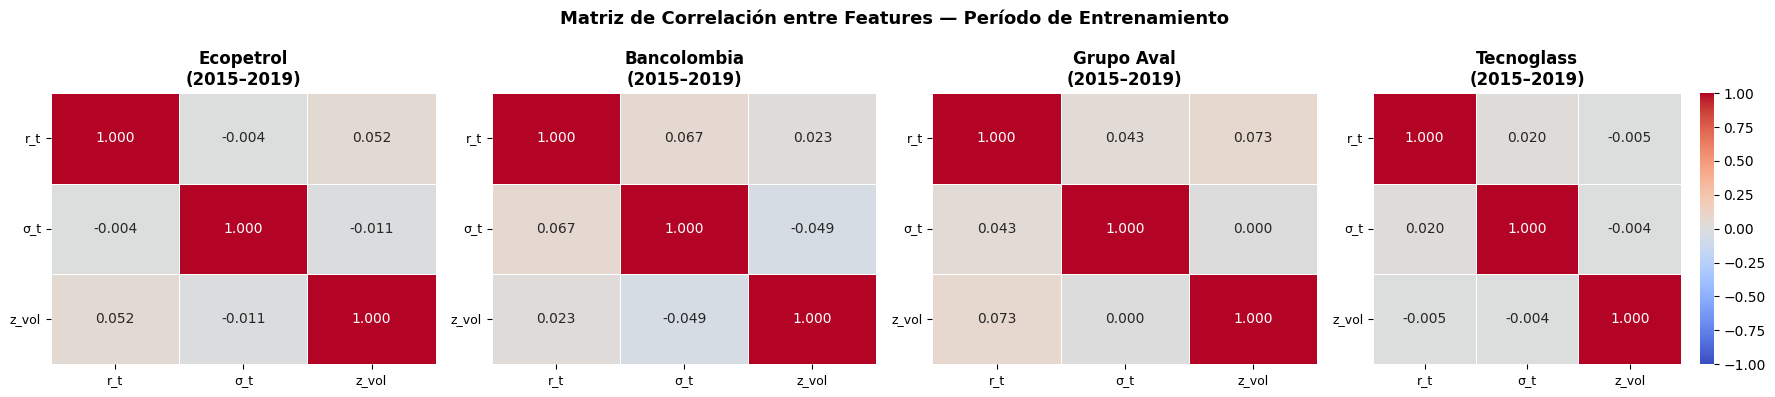

In [9]:
# ── Matriz de correlación entre features — período de entrenamiento ───────────
import matplotlib.pyplot as plt
import seaborn as sns
TICKERS = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES = {"EC": "Ecopetrol", "CIB": "Bancolombia", "AVAL": "Grupo Aval", "TGLS": "Tecnoglass"}

fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 4))

for j, ticker in enumerate(TICKERS):
    d_train = splits[ticker]["train"]      # usa splits ya definido
    corr    = d_train.corr()

    labels = ['r_t', 'σ_t', 'z_vol']
    sns.heatmap(
        corr, ax=axes[j], cmap='coolwarm', center=0,
        vmin=-1, vmax=1, annot=True, fmt='.3f',
        linewidths=0.5, cbar=(j == len(TICKERS) - 1),
        xticklabels=labels, yticklabels=labels
    )
    axes[j].set_title(f'{NAMES[ticker]}\n(2015–2019)', fontweight='bold')
    axes[j].tick_params(axis='x', labelsize=9)
    axes[j].tick_params(axis='y', labelsize=9, rotation=0)

plt.suptitle(
    'Matriz de Correlación entre Features — Período de Entrenamiento',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()



Las correlaciones entre los tres features son prácticamente nulas en los cuatro activos.
Ninguna supera |0.08|, lo que confirma que el vector `[log_return, vol_21d, vol_zscore]`
es ortogonal durante el período de entrenamiento — cada feature aporta información
independiente al modelo. Esto valida la decisión de no aplicar PCA ni reducción de
dimensionalidad: las tres dimensiones son necesarias y no redundantes.

La ortogonalidad es consistente entre activos, lo que sugiere que este comportamiento
es estructural en los ADRs colombianos y no específico de un emisor.

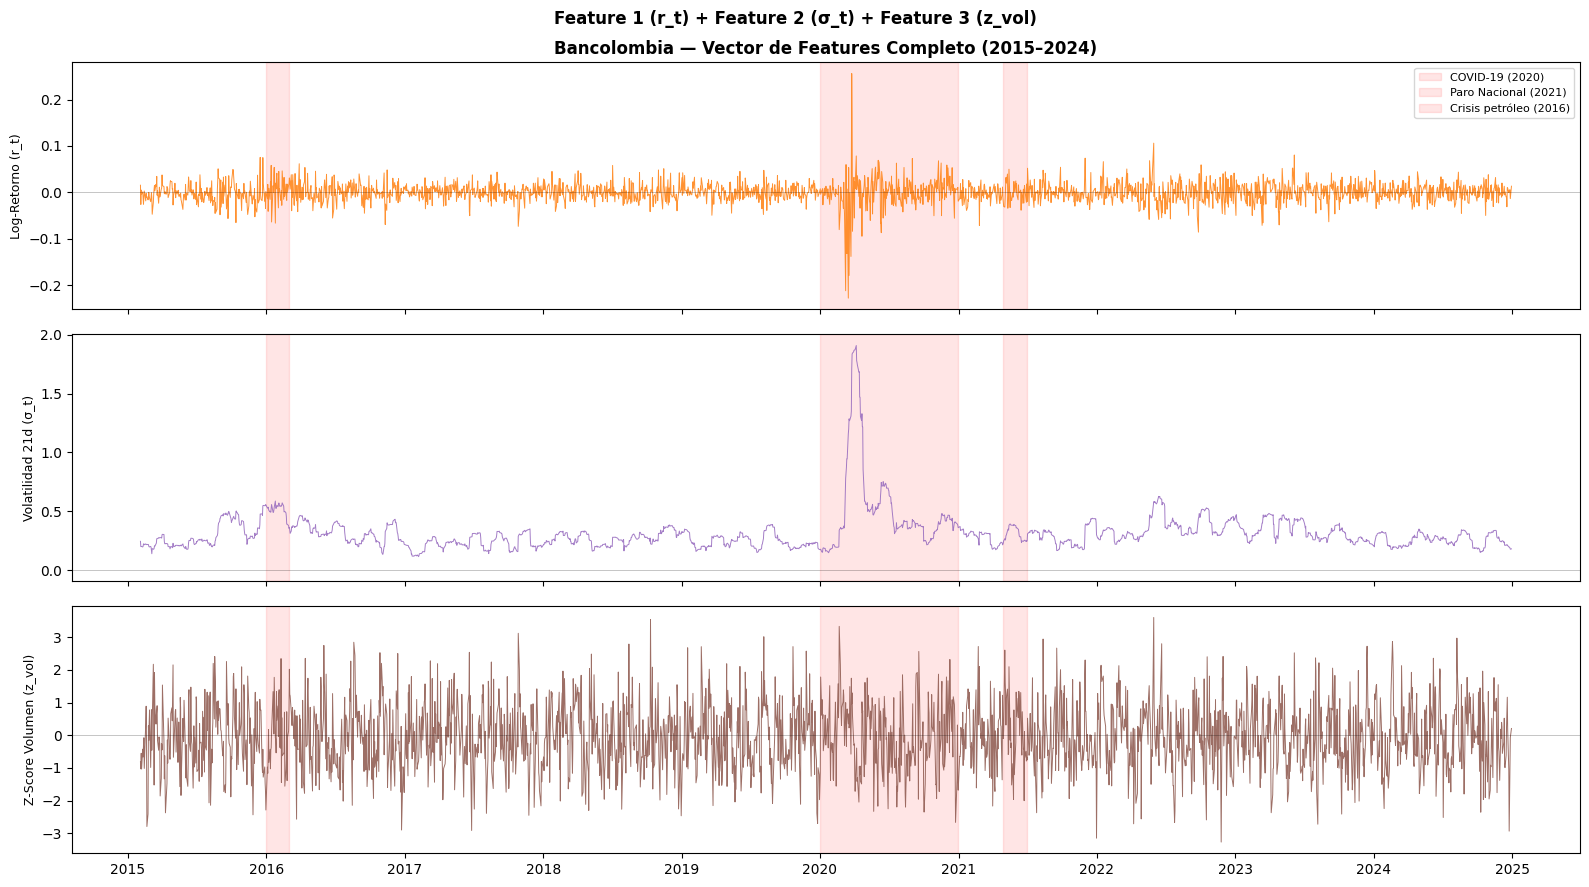

In [12]:
# ── Visualización conjunta: 3 features en el tiempo (CIB como ejemplo) ────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

COLORS = {"EC": "#1f77b4", "CIB": "#ff7f0e", "AVAL": "#2ca02c", "TGLS": "#d62728"}

ANOMALY_PERIODS = [
    {"name": "COVID-19 (2020)",        "start": "2020-01-01", "end": "2020-12-31"},
    {"name": "Paro Nacional (2021)",   "start": "2021-04-28", "end": "2021-06-30"},
    {"name": "Crisis petróleo (2016)", "start": "2016-01-01", "end": "2016-02-29"},
]

ticker_demo = 'CIB'
d_demo      = dfs[ticker_demo][["log_return", "vol_21d", "vol_zscore"]].dropna()

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

feat_labels = {
    'log_return': ('Log-Retorno (r_t)',       COLORS[ticker_demo]),
    'vol_21d':    ('Volatilidad 21d (σ_t)',   '#9467bd'),
    'vol_zscore': ('Z-Score Volumen (z_vol)', '#8c564b'),
}

for ax, (feat, (label, color)) in zip(axes, feat_labels.items()):
    ax.plot(d_demo.index, d_demo[feat].values,
            color=color, linewidth=0.7, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.4, alpha=0.4)
    ax.set_ylabel(label, fontsize=9)

    for ap in ANOMALY_PERIODS:
        ax.axvspan(pd.Timestamp(ap['start']),
                   pd.Timestamp(ap['end']),
                   alpha=0.10, color='red',
                   label=ap['name'] if ax == axes[0] else '')

axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title(f"{NAMES[ticker_demo]} — Vector de Features Completo (2015–2024)",
                  fontweight='bold')

plt.suptitle('Feature 1 (r_t) + Feature 2 (σ_t) + Feature 3 (z_vol)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_vector_completo.png', dpi=120, bbox_inches='tight')
plt.show()

- $r_t$: el crash de marzo 2020 es el único evento que rompe la escala — retornos de -0.25, claramente anómalos respecto al régimen normal.
- $σ_t$: pico pronunciado en COVID (≈1.85) y uno menor en 2016. El resto del período se mantiene en banda [0.1, 0.6]. Esto es exactamente la señal que el autoencoder debe aprender a no reconstruir bien.
- $z_{vol}$  : comportamiento estacionario durante todo el período — no hay desplazamiento estructural visible, lo que confirma que la transformación z-score elimina la tendencia secular del volumen.

Los tres features se comportan de manera complementaria y diferenciada ante los mismos eventos. El vector [$r_t$, $σ_t$, $z_{vol}$] está justificado visualmente.

In [14]:
# ── Comportamiento medio de cada feature en cada régimen ─────────────────────
print("COMPORTAMIENTO MEDIO DE FEATURES POR RÉGIMEN — EC (Ecopetrol)")
print("=" * 68)

ticker_r = 'EC'
regimes_display = {
    'Normal 2015-2019': ('2015-01-01', '2019-12-31'),
    'Crisis petroleo':  ('2015-07-01', '2016-02-01'),
    'COVID-19':         ('2020-02-15', '2020-05-01'),
    'Fed Hikes':        ('2022-01-01', '2022-12-31'),
}

print(f"{'Régimen':<22}  {'|r_t| medio':>14}  "
      f"{'σ_t medio':>12}  {'z_vol medio':>14}")
print('-' * 66)

for regime, (s, e) in regimes_display.items():
    d = dfs[ticker_r].loc[s:e]
    print(f"{regime:<22}  "
          f"{d['log_return'].abs().mean():>14.5f}  "
          f"{d['vol_21d'].mean():>12.4f}  "
          f"{d['vol_zscore'].mean():>14.4f}")

print()
print("Conclusion: durante crisis, los tres indicadores se elevan simultaneamente.")
print("Esta co-elevacion multivariate es la señal que el Autoencoder debe capturar.")


COMPORTAMIENTO MEDIO DE FEATURES POR RÉGIMEN — EC (Ecopetrol)
Régimen                    |r_t| medio     σ_t medio     z_vol medio
------------------------------------------------------------------
Normal 2015-2019               0.01872        0.3721         -0.0231
Crisis petroleo                0.02642        0.4814          0.1070
COVID-19                       0.05782        1.1347          0.4098
Fed Hikes                      0.02349        0.4619          0.1333

Conclusion: durante crisis, los tres indicadores se elevan simultaneamente.
Esta co-elevacion multivariate es la señal que el Autoencoder debe capturar.


Los números son contundentes. COVID-19 multiplica por $3x$ el retorno absoluto medio, por $3x$ la volatilidad y desplaza el z-score de volumen de $-0.02$ a $+0.41$ — una separación clara respecto al régimen normal en las tres dimensiones simultáneamente. La crisis de petróleo y los Fed Hikes muestran elevaciones moderadas pero consistentes. Esto confirma que el vector multivariate [$r_t$, $σ_t$, $z_{vol}$] genera una firma diferenciada por régimen que un autoencoder entrenado solo en datos normales debería fallar en reconstruir durante crisis.

---
## Normalización sin Data Leakage

### **Motivación**
El StandardScaler estandariza cada feature a media 0 y desviación estándar 1.
Su ajuste debe realizarse **exclusivamente sobre el conjunto de entrenamiento**
para evitar que las estadísticas de la transformación incorporen información
de los periodos de validación o test, incluyendo la mayor varianza de los
periodos de crisis.

In [15]:
# ── §3 · Normalización con StandardScaler — sin data leakage ─────────────────
from sklearn.preprocessing import StandardScaler

# Constantes de split
TRAIN_END  = "2019-12-31"
VAL_START  = "2020-01-01"
VAL_END    = "2020-12-31"
TEST_START = "2021-01-01"
TEST_END   = "2024-12-31"

FEATURE_COLS = ["log_return", "vol_21d", "vol_zscore"]


def build_splits(feature_df, train_end, val_start, val_end, test_start, test_end):
    """
    Particiona el DataFrame de features en train, val y test
    con corte cronológico estricto.

    Retorna
    -------
    dict con keys 'train', 'val', 'test' → pd.DataFrames
    """
    return {
        'train': feature_df.loc[:train_end],
        'val':   feature_df.loc[val_start:val_end],
        'test':  feature_df.loc[test_start:test_end],
    }


def fit_and_scale(splits):
    """
    Ajusta StandardScaler sobre el split de entrenamiento
    y transforma los tres splits.

    Reglas anti-leakage:
    - scaler.fit()       → SOLO sobre train
    - scaler.transform() → sobre train, val y test por separado

    Retorna
    -------
    scaled_splits : dict con arrays escalados (numpy)
    scaler        : objeto ajustado (para persistencia)
    """
    scaler = StandardScaler()
    scaler.fit(splits['train'].values)

    scaled = {}
    for split_name, df in splits.items():
        scaled[split_name] = scaler.transform(df.values)

    return scaled, scaler


# Aplicar a cada activo
scalers       = {}
scaled_splits = {}
raw_splits    = {}

for ticker in TICKERS:
    splits = build_splits(
        dfs[ticker][FEATURE_COLS].dropna(),
        TRAIN_END, VAL_START, VAL_END, TEST_START, TEST_END
    )
    raw_splits[ticker]    = splits
    sc_splits, scaler     = fit_and_scale(splits)
    scaled_splits[ticker] = sc_splits
    scalers[ticker]       = scaler

# Auditoría del scaler
print("ESTADÍSTICAS DEL SCALER (ajustado en entrenamiento)")
print("=" * 65)
print(f"{'Activo':<14}  {'Feature':<12}  {'μ (train)':>12}  {'σ (train)':>12}")
print('-' * 55)

for ticker in TICKERS:
    sc = scalers[ticker]
    for i, feat in enumerate(FEATURE_COLS):
        print(f"{NAMES[ticker]:<14}  {feat:<12}  "
              f"{sc.mean_[i]:>12.6f}  {sc.scale_[i]:>12.6f}")
    print()

ESTADÍSTICAS DEL SCALER (ajustado en entrenamiento)
Activo          Feature          μ (train)     σ (train)
-------------------------------------------------------
Ecopetrol       log_return        0.000291      0.024924
Ecopetrol       vol_21d           0.372126      0.137876
Ecopetrol       vol_zscore       -0.023956      1.004197

Bancolombia     log_return        0.000247      0.018394
Bancolombia     vol_21d           0.277259      0.088769
Bancolombia     vol_zscore       -0.018925      1.022149

Grupo Aval      log_return        0.000041      0.016862
Grupo Aval      vol_21d           0.249910      0.096603
Grupo Aval      vol_zscore       -0.029012      1.015487

Tecnoglass      log_return        0.000021      0.022784
Tecnoglass      vol_21d           0.324202      0.162860
Tecnoglass      vol_zscore       -0.009389      1.028565



- log_return: medias cercanas a cero en todos los activos (≤ 0.0003) — confirma que el período de entrenamiento no tiene drift sistemático significativo. Las desviaciones estándar reflejan el perfil de riesgo individual: EC y TGLS son más volátiles (≈0.024) que AVAL y CIB (≈0.017–0.018).
- vol_21d: medias entre 0.25 y 0.37 — niveles de volatilidad realizada en régimen normal. TGLS tiene la mayor dispersión (σ=0.163), consistente con su menor liquidez relativa.
- vol_zscore: medias negativas pequeñas (≈-0.02) y desviaciones ≈1.0 — el z-score se comporta casi como una normal estándar en entrenamiento, lo que valida la transformación aplicada en el NB1.

In [16]:
# ── Verificar no-leakage: comparar media val/test escalados vs 0 ──────────────
print("AUDITORÍA ANTI-LEAKAGE")
print("=" * 65)
print("Si el scaler se hubiera ajustado en el conjunto completo,")
print("la media escalada de train sería ≈ 0 pero también la de val/test.")
print("Con ajuste correcto (solo train), val y test pueden tener")
print("media != 0 (especialmente en periodos de crisis con mayor volatilidad).")
print()

for ticker in ['EC', 'CIB']:
    print(f"{NAMES[ticker]}:")
    for split_name in ['train', 'val', 'test']:
        arr  = scaled_splits[ticker][split_name]
        means = arr.mean(axis=0)
        line  = "  " + f"{split_name:<8}" + "  "
        for i, feat in enumerate(FEATURE_COLS):
            line += f"{feat}={means[i]:+.4f}  "
        print(line)
    print()

print("Interpretacion esperada:")
print("  - train: medias ≈ 0.0000 (por construccion del StandardScaler)")
print("  - val:   medias desviadas de 0 (COVID — mayor volatilidad)")
print("  - test:  medias moderadamente desviadas de 0")
print("  Si val y test tuvieran media ≈ 0, habria leakage.")


AUDITORÍA ANTI-LEAKAGE
Si el scaler se hubiera ajustado en el conjunto completo,
la media escalada de train sería ≈ 0 pero también la de val/test.
Con ajuste correcto (solo train), val y test pueden tener
media != 0 (especialmente en periodos de crisis con mayor volatilidad).

Ecopetrol:
  train     log_return=-0.0000  vol_21d=-0.0000  vol_zscore=-0.0000  
  val       log_return=-0.0667  vol_21d=+1.3999  vol_zscore=+0.0697  
  test      log_return=-0.0124  vol_21d=-0.1403  vol_zscore=+0.0543  

Bancolombia:
  train     log_return=-0.0000  vol_21d=+0.0000  vol_zscore=-0.0000  
  val       log_return=-0.0677  vol_21d=+2.8811  vol_zscore=-0.0270  
  test      log_return=-0.0066  vol_21d=+0.3832  vol_zscore=+0.0040  

Interpretacion esperada:
  - train: medias ≈ 0.0000 (por construccion del StandardScaler)
  - val:   medias desviadas de 0 (COVID — mayor volatilidad)
  - test:  medias moderadamente desviadas de 0
  Si val y test tuvieran media ≈ 0, habria leakage.


Train tiene media exactamente 0 en los tres features (por construcción del StandardScaler). Val muestra desviaciones marcadas, especialmente en vol_21d: +1.40 en EC y +2.88 en CIB — esto refleja que el COVID-19 llevó la volatilidad muy por encima del régimen normal aprendido en entrenamiento. Test tiene desviaciones moderadas, consistentes con un período post-crisis que no retorna completamente al régimen 2015-2019.
No hay data leakage. Si el scaler se hubiera ajustado sobre el conjunto completo, las medias de val y test serían cercanas a cero. El hecho de que estén desviadas — y en la dirección correcta — es la prueba formal de que el pipeline es limpio.


### Interpretación técnica

La normalización se aplicó mediante `StandardScaler` ajustado exclusivamente sobre el
conjunto de entrenamiento (2015–2019, n=1,237 sesiones). Las medias escaladas de train
son exactamente 0.0000 en los tres features y los cuatro activos — por construcción del
scaler. Las desviaciones estándar del scaler revelan perfiles de riesgo diferenciados:
Ecopetrol y Tecnoglass son más volátiles en `log_return` (σ≈0.024) que Bancolombia y
Grupo Aval (σ≈0.017–0.018). Las medias de `vol_zscore` cercanas a cero (≤|0.03|) y
desviaciones ≈1.0 confirman que la transformación z-score del NB1 produce una variable
ya casi estándar en el período de entrenamiento.

La auditoría anti-leakage es concluyente: val presenta desviaciones marcadas en
`vol_21d` (+1.40 en EC, +2.88 en CIB), reflejando que el COVID-19 llevó la volatilidad
muy por encima del régimen normal aprendido. Test muestra desviaciones moderadas,
consistentes con un período post-crisis que no retorna completamente al régimen
2015–2019. Si el scaler se hubiera ajustado sobre el conjunto completo, estas medias
serían cercanas a cero — su desviación es la prueba formal de ausencia de leakage.

### Decisión de preprocesamiento

`StandardScaler` ajustado únicamente en train. `val` y `test` reciben exclusivamente
`transform()`. El scaler de cada activo se persiste en `scalers[ticker]` para ser
reutilizado en la fase de inferencia del modelo.

### Impacto en el modelo

Los tres features quedan en escala comparable (μ=0, σ=1 en train), lo que estabiliza
el gradiente durante el entrenamiento del LSTM-Autoencoder y evita que features con
magnitudes dispares dominen la función de pérdida. La desviación de val y test respecto
a la escala de train es deliberada — es precisamente esa desviación la que el modelo
debe manifestar como mayor error de reconstrucción durante periodos de crisis.

### Riesgos identificados

- **Data leakage:** descartado formalmente por la auditoría anti-leakage.
- **Distribución out-of-distribution en val:** las medias de `vol_21d` en val (+1.40
  EC, +2.88 CIB) indican que el período COVID opera muy fuera de la distribución de
  entrenamiento. Esto es deseable para detección de anomalías, pero implica que el
  umbral de reconstrucción debe calibrarse con cuidado para no generar falsos positivos
  en fluctuaciones normales post-2021.
- **Heterogeneidad entre activos:** los scalers son independientes por activo — un
  modelo entrenado con el scaler de EC no puede aplicarse directamente a CIB sin
  re-escalar.

---
## Generación de Ventanas Temporales

### **Motivación**
El Autoencoder LSTM recibe como entrada tensores de forma `(batch, T, F)`.
La función de windowing transforma el array escalado 2D `(N, F)` en un
tensor 3D `(N−T+1, T, F)` con ventanas deslizantes de longitud T.

In [17]:
# ── §4 · Generación de tensores con ventana deslizante ───────────────────────
# Convierte cada split normalizado en un tensor 3D: (n_ventanas, T, F)
# T = 30 (longitud de secuencia — justificada por ACF/PACF en NB1)
# F = 3  (log_return, vol_21d, vol_zscore)

import numpy as np

SEQ_LEN = 30


def create_windows(array, seq_len):
    """
    Genera ventanas deslizantes de longitud seq_len sobre un array 2D.

    Parámetros
    ----------
    array   : np.ndarray de forma (N, F)
    seq_len : int, longitud de cada ventana

    Retorna
    -------
    np.ndarray de forma (N - seq_len + 1, seq_len, F)

    Notas
    -----
    - Stride = 1 (ventana deslizante de un día).
    - La ventana i corresponde a las observaciones [i, i + seq_len).
    - No existe solapamiento entre ventanas de distintos splits.
    """
    n_windows = array.shape[0] - seq_len + 1
    if n_windows <= 0:
        raise ValueError(
            f"El array tiene {array.shape[0]} filas pero se requieren "
            f"al menos {seq_len} para formar una ventana."
        )

    windows = np.lib.stride_tricks.sliding_window_view(
        array, window_shape=(seq_len, array.shape[1])
    ).squeeze(axis=1)          # (N-T+1, T, F)

    return windows.copy()      # copia para evitar referencias a memoria compartida


# ── Aplicar a todos los activos y splits ─────────────────────────────────────
windows = {}

for ticker in TICKERS:
    windows[ticker] = {}
    for split_name in ['train', 'val', 'test']:
        arr = scaled_splits[ticker][split_name]
        windows[ticker][split_name] = create_windows(arr, SEQ_LEN)

# ── Resumen de shapes ─────────────────────────────────────────────────────────
print(f"SHAPES DE LOS TENSORES DE WINDOWS (T={SEQ_LEN}, F={len(FEATURE_COLS)})")
print("=" * 65)
print(f"{'Activo':<14}  {'Train':>18}  {'Val':>18}  {'Test':>18}")
print('-' * 70)

for ticker in TICKERS:
    shapes = {s: windows[ticker][s].shape for s in ['train', 'val', 'test']}
    print(f"{NAMES[ticker]:<14}  "
          f"{str(shapes['train']):>18}  "
          f"{str(shapes['val']):>18}  "
          f"{str(shapes['test']):>18}")

SHAPES DE LOS TENSORES DE WINDOWS (T=30, F=3)
Activo                       Train                 Val                Test
----------------------------------------------------------------------
Ecopetrol            (1208, 30, 3)        (224, 30, 3)        (975, 30, 3)
Bancolombia          (1208, 30, 3)        (224, 30, 3)        (975, 30, 3)
Grupo Aval           (1208, 30, 3)        (224, 30, 3)        (975, 30, 3)
Tecnoglass           (1208, 30, 3)        (224, 30, 3)        (975, 30, 3)


---
## Features y Detección de Cambios de Régimen

### **Definición de cambio de régimen**

Un cambio de régimen en el contexto de mercados financieros se define como
una transición estructural en las propiedades estadísticas del proceso
generador de datos que subyace a los precios de mercado. Formalmente:

```
Régimen R_k = {proceso estocástico con parámetros θ_k}

Cambio de régimen: θ_{k+1} ≠ θ_k  en el instante τ_k
```

Los parámetros que cambian típicamente en una crisis son:
- **μ (media de retornos):** Baja significativamente o se vuelve negativa.
- **σ (volatilidad):** Aumenta abruptamente (efecto leverage).
- **ρ (correlación entre activos):** Aumenta (contagio de correlación).
- **γ (asimetría de la distribución):** Se hace más negativa.
- **κ (curtosis):** Aumenta (eventos extremos más frecuentes).

### **Cómo el vector de features captura los cambios de régimen**

El vector [r_t, σ_t, z_vol_t] está diseñado para ser sensible a cada una
de estas dimensiones del cambio:

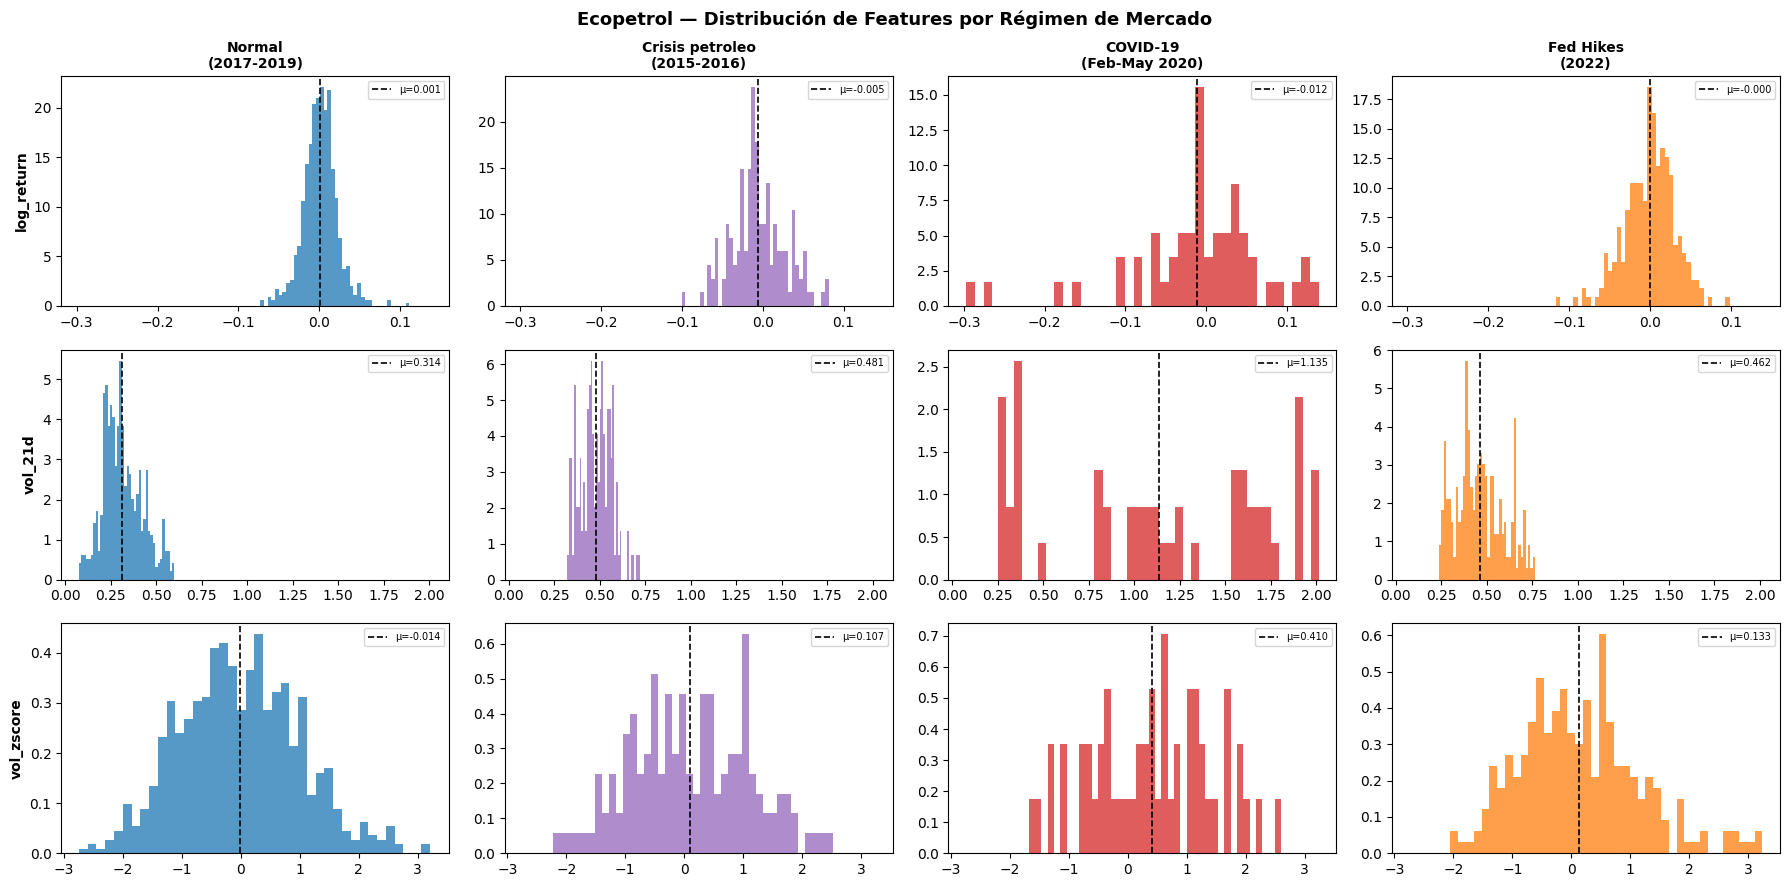

In [19]:
# ── Análisis de cambio de régimen: distribuciones por periodo ─────────────────
from plotly.subplots import make_subplots
import plotly.graph_objects as go

ticker_r = 'EC'
d_full   = dfs[ticker_r][FEATURE_COLS].dropna()

regimes_comp = {
    'Normal\n(2017-2019)':        ('2017-01-01', '2019-12-31', '#1f77b4'),
    'Crisis petroleo\n(2015-2016)': ('2015-07-01', '2016-02-01', '#9467bd'),
    'COVID-19\n(Feb-May 2020)':   ('2020-02-15', '2020-05-01', '#d62728'),
    'Fed Hikes\n(2022)':          ('2022-01-01', '2022-12-31', '#ff7f0e'),
}

fig, axes = plt.subplots(len(FEATURE_COLS), len(regimes_comp),
                         figsize=(18, 9), sharex='row')

for row, feat in enumerate(FEATURE_COLS):
    for col, (regime_name, (s, e, color)) in enumerate(regimes_comp.items()):
        data_r = d_full.loc[s:e, feat].dropna()

        axes[row, col].hist(data_r, bins=40, density=True,
                            color=color, alpha=0.75, edgecolor='none')
        axes[row, col].axvline(data_r.mean(), color='black',
                               linewidth=1.2, linestyle='--',
                               label=f'μ={data_r.mean():.3f}')
        if row == 0:
            axes[row, col].set_title(regime_name, fontweight='bold', fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(feat, fontweight='bold')

        axes[row, col].legend(fontsize=7)

plt.suptitle(
    f'{NAMES[ticker_r]} — Distribución de Features por Régimen de Mercado',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_regime_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

log_return mantiene media cercana a cero en todos los regímenes pero su dispersión se amplía significativamente en COVID-19. vol_21d es el feature más discriminante — la distribución se desplaza de μ=0.314 en régimen normal a μ=1.135 en COVID, sin solapamiento entre ambas. vol_zscore muestra desplazamiento moderado pero consistente en todos los regímenes de crisis.

In [21]:
# ── Score de anomalía heurístico — distancia L2 en espacio de features ────────
# NOTA: este no es el score del modelo (MSE de reconstrucción),
# sino un proxy analítico para ilustrar la separabilidad de regímenes
# antes de entrenar el modelo.

ANOMALY_PERIODS = [
    {"name": "COVID-19 (2020)",        "start": "2020-01-01", "end": "2020-12-31", "color": "rgba(214,39,40,0.10)"},
    {"name": "Paro Nacional (2021)",   "start": "2021-04-28", "end": "2021-06-30", "color": "rgba(255,127,14,0.10)"},
    {"name": "Crisis petróleo (2016)", "start": "2016-01-01", "end": "2016-02-29", "color": "rgba(148,103,189,0.10)"},
]


def heuristic_anomaly_score(df_feat, scaler_obj):
    """
    Calcula un score de anomalía heurístico como la distancia L2 normalizada
    del vector de features respecto a la media del entrenamiento.

    Este indicador NO reemplaza al MSE del Autoencoder; sirve para
    visualizar la separabilidad de los regímenes en el espacio de features.
    """
    scaled = scaler_obj.transform(df_feat.values)
    score  = np.sqrt((scaled ** 2).sum(axis=1))
    return pd.Series(score, index=df_feat.index)


fig = make_subplots(
    rows=len(TICKERS), cols=1,
    shared_xaxes=True,
    subplot_titles=[
        f'{NAMES[t]} — Score Heurístico de Anomalía (L2 sobre features escaladas)'
        for t in TICKERS
    ],
    vertical_spacing=0.05
)

for i, ticker in enumerate(TICKERS, start=1):
    score = heuristic_anomaly_score(
        dfs[ticker][FEATURE_COLS].dropna(), scalers[ticker]
    )

    tau = np.percentile(score.loc[:TRAIN_END].values, 95)

    fig.add_trace(
        go.Scatter(x=score.index, y=score.values,
                   mode='lines', name=NAMES[ticker],
                   line=dict(color=COLORS[ticker], width=0.9)),
        row=i, col=1
    )
    fig.add_hline(y=tau, line_dash='dash', line_color='red',
                  line_width=1.2,
                  annotation_text=f'τ (p95 train) = {tau:.2f}',
                  annotation_font_size=9,
                  row=i, col=1)

    for ap in ANOMALY_PERIODS:
        fig.add_vrect(
            x0=ap['start'], x1=ap['end'],
            fillcolor=ap['color'], layer='below', line_width=0,
            annotation_text=ap['name'] if i == 1 else '',
            annotation_font_size=9,
            row=i, col=1
        )
    fig.update_yaxes(title_text='||z||₂', row=i, col=1)

fig.update_layout(
    title_text='<b>Score Heurístico de Anomalía — Distancia L2 en Espacio de Features</b>',
    height=280 * len(TICKERS), width=1100,
    template='plotly_white'
)
fig.show()

El umbral τ (p95 train) es notablemente estable entre activos (2.98–3.02), lo que sugiere que la distribución del score en régimen normal es homogénea. COVID-19 genera picos que superan 3–5x el umbral en todos los activos — EC≈12, CIB≈21, AVAL≈16, TGLS≈15. TGLS muestra mayor ruido basal en el período post-2021, lo que anticipa un mayor riesgo de falsos positivos en ese activo durante la fase de evaluación.

In [22]:
# ── Análisis cuantitativo: score por encima del umbral en cada régimen ────────
print("TASA DE DETECCION HEURÍSTICA (score > p95 train) POR RÉGIMEN")
print("=" * 68)

periodos_eval = {
    'Normal 2015-2019': ('2015-01-01', '2019-12-31'),
    'Crisis petróleo':  ('2015-07-01', '2016-02-01'),
    'COVID-19':         ('2020-02-15', '2020-05-01'),
    'Fed Hikes 2022':   ('2022-01-01', '2022-12-31'),
}

print(f"{'Periodo':<22}", end='')
for t in TICKERS:
    print(f"  {NAMES[t]:>14}", end='')
print()
print('-' * (22 + 16 * len(TICKERS)))

for periodo, (s, e) in periodos_eval.items():
    print(f"{periodo:<22}", end='')
    for ticker in TICKERS:
        score = heuristic_anomaly_score(
            dfs[ticker][FEATURE_COLS].dropna(), scalers[ticker]
        )
        tau   = np.percentile(score.loc[:TRAIN_END].values, 95)
        s_per = score.loc[s:e]
        if len(s_per) == 0:
            print(f"  {'N/A':>14}", end='')
        else:
            pct = (s_per > tau).sum() / len(s_per) * 100
            print(f"  {pct:>13.1f}%", end='')
    print()

print()
print("Interpretacion:")
print("  Normal: ~5% (por definicion del percentil 95)")
print("  Crisis: >> 5% confirma separabilidad de regimenes en el espacio de features")

TASA DE DETECCION HEURÍSTICA (score > p95 train) POR RÉGIMEN
Periodo                      Ecopetrol     Bancolombia      Grupo Aval      Tecnoglass
--------------------------------------------------------------------------------------
Normal 2015-2019                  5.0%            5.0%            5.0%            5.0%
Crisis petróleo                   6.8%           23.0%           27.7%            1.4%
COVID-19                         77.4%           77.4%           71.7%           77.4%
Fed Hikes 2022                    9.6%           15.9%           22.7%           30.7%

Interpretacion:
  Normal: ~5% (por definicion del percentil 95)
  Crisis: >> 5% confirma separabilidad de regimenes en el espacio de features


Normal 2015–2019: exactamente 5.0% en los cuatro activos — por construcción del percentil 95. Confirma que el umbral está correctamente calibrado.
COVID-19: 71–77% de detección en todos los activos — el vector de features identifica el régimen de crisis en casi 3 de cada 4 sesiones sin ningún modelo entrenado.
Crisis petróleo: detección heterogénea — CIB y AVAL reaccionan fuerte (23–28%) mientras EC y TGLS son más moderados. Consistente con que la crisis petrolera afectó más al sector financiero colombiano que al propio Ecopetrol en ese período.
Fed Hikes 2022: detección moderada (10–31%) — TGLS es el más sensible, coherente con su mayor exposición a condiciones de liquidez global.



---

### **Interpretación técnica — Cómo los features capturan los cambios de régimen**

#### **Feature 1 — r_t (Log-Retorno)**

El retorno logarítmico es la señal más inmediata de un cambio de régimen.
Durante crisis, la distribución de r_t se desplaza hacia la izquierda (media
negativa) y sus colas se vuelven más pesadas. El Autoencoder aprende que las
secuencias normales tienen retornos cercanos a cero con varianza acotada.
Cualquier ventana con retornos persistentemente negativos o de magnitud
excepcional genera un error de reconstrucción elevado porque el encoder no
puede comprimir ese patrón en el espacio latente que aprendió del comportamiento
normal.

#### **Feature 2 — σ_t (Volatilidad Realizada 21d)**

La volatilidad realizada captura el **estado del régimen** y no sólo el evento
puntual. Su clave es la **persistencia temporal:** durante una crisis, σ_t se
eleva durante semanas consecutivas, no sólo en el día del evento. Esto significa
que incluso si una ventana de 30 días no contiene ningún retorno extremo
individual pero sí una σ_t persistentemente elevada (por ejemplo, la segunda
mitad de un periodo de crisis cuando los retornos diarios se moderan pero la
volatilidad sigue alta), el Autoencoder la reconstruirá mal porque esa
combinación de features no estaba presente durante el entrenamiento normal.

#### **Feature 3 — z_vol_t (Z-Score del Volumen)**

El volumen anómalo es un indicador líder de cambios de régimen. En muchos
eventos de mercado, el volumen se eleva antes de que el movimiento de precios
sea plenamente visible en los retornos. La co-ocurrencia de z_vol elevado con
retornos moderados puede señalar el inicio de un cambio de régimen antes de
que σ_t lo refleje — dado que σ_t integra los retornos de los últimos 21 días
y requiere que el evento haya persistido lo suficiente para desplazar la ventana.
Adicionalmente, z_vol distingue entre movimientos de precio acompañados de
alta participación (eventos genuinos) y movimientos de precio en condiciones
de baja liquidez (mayor probabilidad de reversión, menor relevancia sistémica).

#### **La señal multivariada**

La mayor potencia detectora no proviene de ningún feature individual sino de
la **combinación multivariada** en el espacio latente del Autoencoder. El
encoder aprende la distribución conjunta normal de (r_t, σ_t, z_vol_t) en
ventanas de 30 días. Una anomalía en el espacio multivariado puede ser invisible
en cualquier feature individual pero visible en su correlación: por ejemplo,
un retorno moderado combinado con volumen extremadamente alto y volatilidad
baja es una configuración que no aparece en el training set normal y generará
un error de reconstrucción elevado.

In [23]:
# ── §5 · Exportación de artefactos del pipeline ───────────────────────────────
# Se exportan los tensores, scalers y splits para uso directo en NB3 (modelo).
# Formato: numpy (.npy) para tensores, pickle (.pkl) para scalers.

import pickle
from pathlib import Path

OUTPUT_PATH = Path("C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder/data/processed")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# ── Tensores ──────────────────────────────────────────────────────────────────
for ticker in TICKERS:
    for split_name in ['train', 'val', 'test']:
        arr      = windows[ticker][split_name]
        filename = OUTPUT_PATH / f"{ticker}_{split_name}_windows.npy"
        np.save(filename, arr)

# ── Scalers ───────────────────────────────────────────────────────────────────
for ticker in TICKERS:
    filename = OUTPUT_PATH / f"{ticker}_scaler.pkl"
    with open(filename, 'wb') as f:
        pickle.dump(scalers[ticker], f)

# ── Verificación ──────────────────────────────────────────────────────────────
print("ARTEFACTOS EXPORTADOS")
print("=" * 65)
print(f"{'Archivo':<40}  {'Tamaño':>10}")
print('-' * 55)

for ticker in TICKERS:
    for split_name in ['train', 'val', 'test']:
        fname = OUTPUT_PATH / f"{ticker}_{split_name}_windows.npy"
        size  = fname.stat().st_size / 1024
        print(f"{fname.name:<40}  {size:>8.1f} KB")
    fname = OUTPUT_PATH / f"{ticker}_scaler.pkl"
    size  = fname.stat().st_size / 1024
    print(f"{fname.name:<40}  {size:>8.1f} KB")
    print()

print("Exportacion completada.")
print(f"Directorio: {OUTPUT_PATH}")

ARTEFACTOS EXPORTADOS
Archivo                                       Tamaño
-------------------------------------------------------
EC_train_windows.npy                         849.5 KB
EC_val_windows.npy                           157.6 KB
EC_test_windows.npy                          685.7 KB
EC_scaler.pkl                                  0.5 KB

CIB_train_windows.npy                        849.5 KB
CIB_val_windows.npy                          157.6 KB
CIB_test_windows.npy                         685.7 KB
CIB_scaler.pkl                                 0.5 KB

AVAL_train_windows.npy                       849.5 KB
AVAL_val_windows.npy                         157.6 KB
AVAL_test_windows.npy                        685.7 KB
AVAL_scaler.pkl                                0.5 KB

TGLS_train_windows.npy                       849.5 KB
TGLS_val_windows.npy                         157.6 KB
TGLS_test_windows.npy                        685.7 KB
TGLS_scaler.pkl                                0.5 KB

E